In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns
import numpy as np
import pandas as pd

In [3]:
from sklearn.datasets import fetch_openml
dataset = fetch_openml("mnist_784")
X = dataset["data"]
y = dataset["target"]

In [4]:
seed = 42
y = y.astype(int)

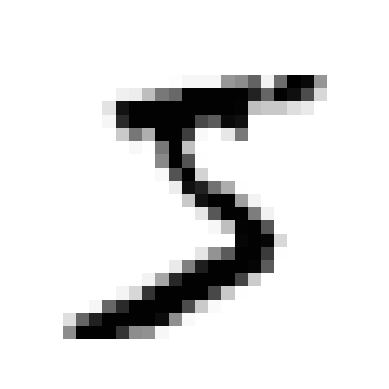

In [5]:
def show_digit(image_vector, label = None):
    # image_vector = np.array(image_vector)
    image_matrix = image_vector.reshape(28, 28)
    plt.imshow(image_matrix, cmap="Grays") # Grays para invertir colores
    # plt.title(f"Digito: {label}")
    plt.axis("off")
    plt.show()

for i in range(1):
    show_digit(np.array(X.iloc[i]))

In [6]:
X_small = X.iloc[0:2000]
y_small  = y[:2000]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_small, y_small, test_size=0.25, random_state=seed)

clf = DecisionTreeClassifier(random_state=seed)
clf.fit(X_train, y_train)
accuracy_clf = accuracy_score(y_test, clf.predict(X_test))

gb_clf = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=seed)
gb_clf.fit(X_train, y_train)
accuracy_gb = accuracy_score(y_test, gb_clf.predict(X_test))

rf_clf = RandomForestClassifier(random_state=seed)
rf_clf.fit(X_train, y_train)
accuracy_rf  = accuracy_score(y_test, rf_clf.predict(X_test))

print(f"""
* Decision Tree:
    Accuracy: {accuracy_clf:.2f}

* Gradient Boosting:
    Accuracy: {accuracy_gb:.2f}

* Random Forest:
    Accuracy: {accuracy_rf:.2f}
""")


* Decision Tree:
    Accuracy: 0.72

* Gradient Boosting:
    Accuracy: 0.88

* Random Forest:
    Accuracy: 0.92



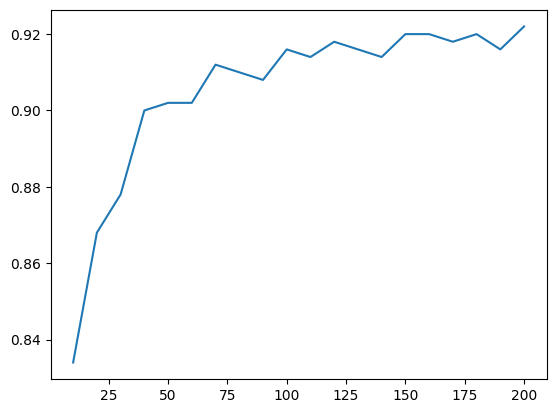

In [8]:
estimators = [i for i in range(10,201,10)]
accuracies = []

for estimator in estimators:
    rf_clf = RandomForestClassifier(n_estimators=estimator, random_state=seed)
    rf_clf.fit(X_train, y_train)
    accuracy_rf = accuracy_score(y_test, rf_clf.predict(X_test))
    accuracies.append(accuracy_rf)

plt.plot(estimators, accuracies)
plt.show()

<Axes: >

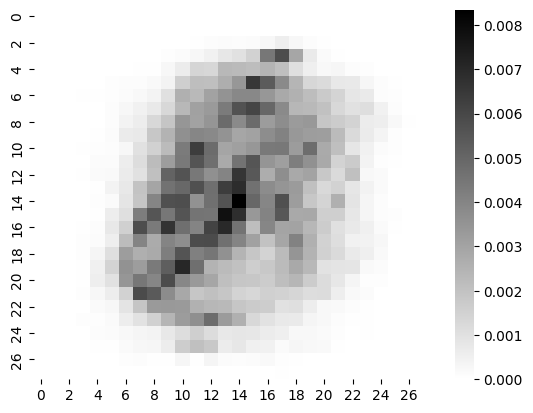

In [9]:
sns.heatmap(np.reshape(rf_clf.feature_importances_, (28, 28)), cmap='binary')

In [333]:
mask_01 = (y == 0) | (y == 1)
X_01 = X[mask_01]
y_01 = y[mask_01]

X_01

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69978,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69983,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69984,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69993,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


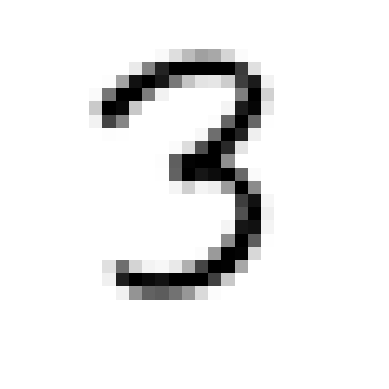

In [30]:
from PIL import Image
import os

path = os.path.join('number_3.jpg')

def cargar_imagen(path):
    img = Image.open(path).convert("L")
    img = img.resize((28, 28))
    img_array = np.array(img)
    if img_array.mean() > 127:
        img_array = 255 - img_array
    img_flat = img_array.reshape(1, -1)
    return img_flat, img_array

show_digit(cargar_imagen(path)[1])

X_3 = cargar_imagen(path)[0]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_small, y_small, test_size=0.25, random_state=seed)

rf_clf = RandomForestClassifier(random_state=seed)
rf_clf.fit(X_train, y_train)
print('Precisión:', accuracy_score(y_test, rf_clf.predict(X_test)))

rf_clf.predict(X_3)

Precisión: 0.916


c:\Users\rock-\Downloads\Facultad\Ciencia_de_Datos\.sklearn-env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([3])

Digito 0: 0.030
Digito 1: 0.020
Digito 2: 0.140
Digito 3: 0.420
Digito 4: 0.030
Digito 5: 0.150
Digito 6: 0.050
Digito 7: 0.060
Digito 8: 0.050
Digito 9: 0.050


c:\Users\rock-\Downloads\Facultad\Ciencia_de_Datos\.sklearn-env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


<BarContainer object of 10 artists>

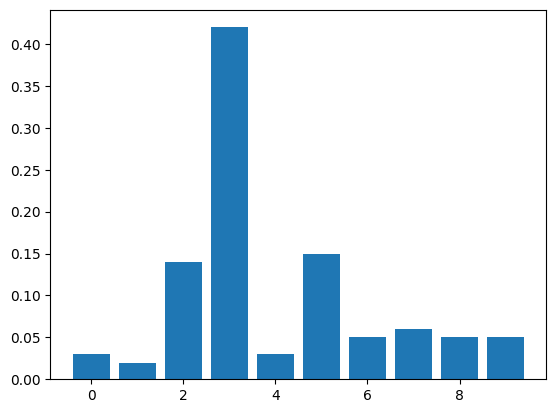

In [ ]:
probas = rf_clf.predict_proba(X_3)
for i, p in enumerate(probas[0]):
    print(f"Digito {i}: {p:.3f}")

plt.bar([i for i in range(10)],probas[0])

#### Tarea 8

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns
import numpy as np
from PIL import Image
import os
import pandas as pd

Primero cargaremos todo el conjunto MNIST.

In [225]:
from sklearn.datasets import fetch_openml
dataset = fetch_openml("mnist_784")
X = dataset["data"]
y = dataset["target"]

Para que los resultados reportados en la presenta entrega sean reproducibles, definiremos una semilla.

In [226]:
seed = 42

Estudiemos los conjuntos que definimos `X` y `y`:

- `X` contiene los píxeles que representan a los dígitos en cuestión. Esta variable es un `DataFrame` con 70,000 filas y 784 columnas. Cada dato es un número entero (entre 0 y 255) que representa un píxel de una cuadrícula de 28 x 28.

- `y` contiene los dígitos. Esta variable es un `Series` con 70,000 datos. Cada dato es del tipo `category`.

In [227]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 784 entries, pixel1 to pixel784
dtypes: int64(784)
memory usage: 418.7 MB


In [228]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 70000 entries, 0 to 69999
Series name: class
Non-Null Count  Dtype   
--------------  -----   
70000 non-null  category
dtypes: category(1)
memory usage: 68.9 KB


Haremos que el conjunto _target_ sean números enteros.

In [229]:
y = y.astype(int)

Visualicemos ahora la distribución del conjunto _target_.

> `np.unique(d, return_counts=True)` devuelve una tupla. El primer elemento es un array con los valores únicos. El segundo elemento es un array con los conteos respectivos.
>
> Esta tupla podemos enchufarla en `plt.bar(x, height)` directamente usando el operador estrella.

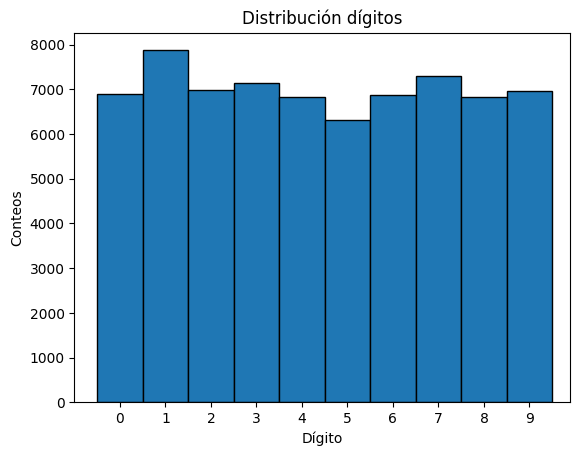

In [230]:
plt.bar(*np.unique(y, return_counts=True), width=1, edgecolor='black')
plt.title('Distribución dígitos')
plt.ylabel('Conteos')
plt.xlim(right=9.9)
plt.xticks(ticks=[i for i in range(10)])
plt.xlabel('Dígito')
plt.show()

Observamos que el dataset no está completamente balanceado, pues hay una cantidad mayor de dígitos 1 y una cantidad menor de dígitos 5. La división en conjuntos de entrenamiento y prueba la haremos usando `stratify`.

En el conjunto de prueba estará 1/7 del total, es decir 10,000 datos.

In [231]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/7, stratify=y, random_state=seed)

Ahora entrenaremos un bosque aleatorio con diferentes valores `n_estimators` hasta encontrar el óptimo. El óptimo lo definiremos como aquel valor tal que cumpla con la siguiente desigualdad:

$$
|Accuracy(n_{actual}) - Accuracy(n_{anterior})|<0.0001
$$

donde $n_{anterior}$ es el valor `n_estimators` que se usó en el entrenamiento previo inmediato y $n_{actual}$ es el `n_estimators` que se se está usando para el actual entrenamiento. El valor de $0.0001$ es una tolerancia, lo que significa que nuestro valor óptimo es aquel cuya precisión en el actual entrenamiento no tiene una mejora con la anterior inmediata más allá de $1\times 10^{-4}$ 

Haremos una iteración sobre `n_estimators` de 20 en 20 en el intervalo [10, 510]. En la variable `best_n` guardaremos el número de árboles óptimos para el modelo y en `accuracies` guardaremos los valores de precisión calculados en cada iteración, esto para observar en una gráfica cómo el modelo evolucionó en cada iteración.

> El parámetro `n_jobs` controla el número de núcleos de CPU que se usarán en paralelo para entrenar el modelo; con esto se construyen varios árboles al mismo tiempo. Hacemos `n_jobs = -1` para usar todos los núcleos disponibles en la CPU. Con esto mejoramos la velocidad sin cambiar el rendimiento del modelo.

In [ ]:
accuracies = []

max_trees = 500 # Número máximo de árboles
tolerance = 0.0001  # Cambio mínimo aceptable en accuracy

prev_acc = 0    # Precisión previa inmediata
best_n = 1  # Valor óptimo

for n in range(10, max_trees+11, 20):
    rf = RandomForestClassifier(n_estimators=n, n_jobs=-1, random_state=seed)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    accuracies.append(acc)

    if abs(acc - prev_acc) < tolerance:
        best_n = n
        break

    prev_acc = acc

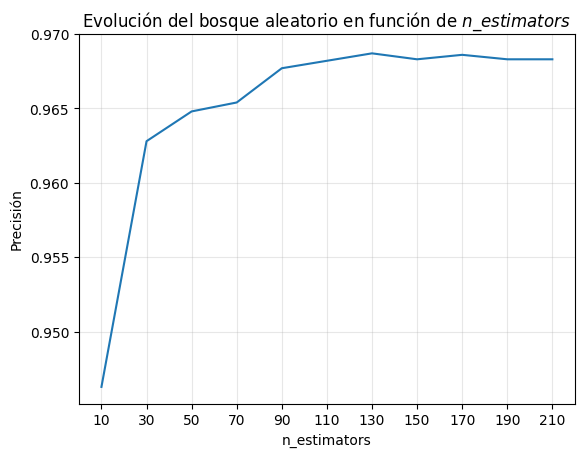

In [210]:
plt.plot([i for i in range(10, best_n+1, 20)], accuracies)
plt.title("Evolución del bosque aleatorio en función de $n\\_estimators$")
plt.xlabel("n_estimators")
plt.ylim(top=0.97)
plt.xticks([i for i in range(10, 220, 20)])
plt.ylabel("Precisión")
plt.grid(True, alpha=0.3)
plt.show()

En la gráfica se aprecia cómo la precisión mejora a medida que el número de árboles aumenta. Llega un punto donde el modelo no mejora más y la precisión presenta ligeras variaciones. Estas variaciones son debido a que el modelo con un nuevo valor de `n_estimators` es distinto al entrenado anteriormente, por lo que si el modelo ya alcanzó la estabilidad, el añadir más árboles no ocasiona un cambio sustancial en la precisión. Por otro lado, el modelo está siendo entrenado con el mismo conjunto de entrenamiento y evaluado con el mismo conjunto de prueba; emplear la técnica de validación cruzada y promediar las precisiones ayudaría a minimizar estas variaciones. Como mencionamos anteriormente, el modelo no mejora más, lo que significa que alcanzó un valor `n_estimators` óptimo, el cuál fue de **210 árboles**. Como el método que estamos empleado consiste en comparar el valor absoluto de la diferencia de precisiones con respeto a la tolerancia, si las variaciones son mayores o iguales que este valor entonces la iteración sobre `n_estimators` continua hasta que la condición de que sean menores se cumpla. El valor óptimo que obtuvimos fue hasta que la condición se cumplió aunque de la gráfica, a ojo, podríamos decir que alrededor de `n_estimators = 130` el modelo es estable.

Ya con el modelo entrenado, podemos obtener la importancia de las 784 características del MNIST. Haremos una visualización de estas importancias en una cuadrícula de 28 x 28.

En color blanco observamos los píxeles que tienen nula importancia en la clasificación, en negro los que tienen más importancia en la toma de decisiones. Notamos que es en la parte central en donde el modelo evalúa las principales diferencias entre cada uno de los dígitos.


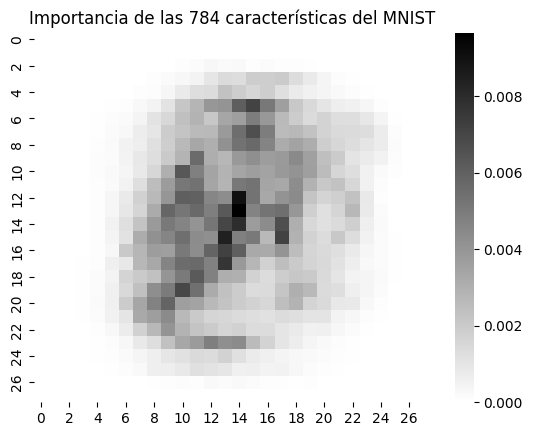

In [217]:
sns.heatmap(np.reshape(rf.feature_importances_, (28, 28)), cmap='binary')
plt.title('Importancia de las 784 características del MNIST')
plt.show()

A continuación definimos una función que nos permite visualizar individualmente los dígitos dentro de MNIST.

In [293]:
def show_digit(image_vector, label:str|int = None):
    '''
    Esta función muestra la imagen de un número en una cuadrícula de 28 x 28 píxeles.

    :param image_vector: 1D np.array de tamaño 784 

        Píxeles que representan al número.

    :param label: str o int 
        
        Dígito.

    :return: None    
    '''
    image_matrix = image_vector.reshape(28, 28)
    plt.imshow(image_matrix, cmap="Grays") # Grays para invertir colores
    plt.title(f"Dígito MNIST: {label}")
    plt.axis("off")
    plt.show()

Mostramos el dígito número 43 del MNIST.

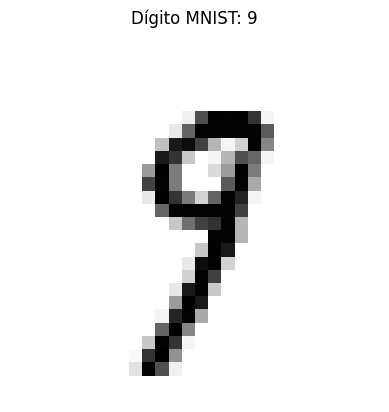

In [294]:
index = 43
show_digit(np.array(X.iloc[index]), y[index])

Como nuestro modelo ya está entrenado, podemos probarlo con dígitos realizados personalmente, para ello

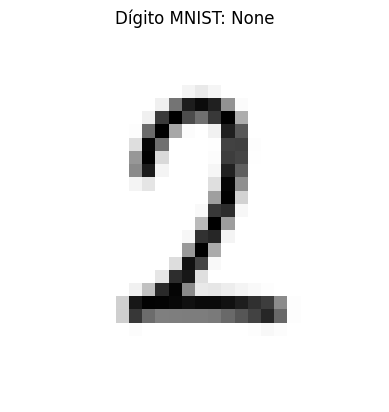

In [291]:
path = os.path.join('j_2.jpg')

def cargar_imagen(path):
    img = Image.open(path).convert("L")
    img = img.resize((28, 28))
    img_array = np.array(img)
    if img_array.mean() > 127:
        img_array = 255 - img_array
    img_flat = img_array.reshape(1, -1)
    return img_flat, img_array

show_digit(cargar_imagen(path)[1])

X_3 = cargar_imagen(path)[0]

In [296]:
X.head(2)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
imagenes = []
for i in range(0, 10):
    path = os.path.join(f'j_{i}.jpg')
    imagenes.append(cargar_imagen(path)[0])

pd.DataFrame(np.squeeze(np.array(imagenes), axis=1))

(10, 1, 784)


,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [325]:
rf.predict(pd.DataFrame(np.squeeze(np.array(imagenes), axis=1)))

c:\Users\rock-\Downloads\Facultad\Ciencia_de_Datos\.sklearn-env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Digito 0: 0.005
Digito 1: 0.033
Digito 2: 0.790
Digito 3: 0.029
Digito 4: 0.005
Digito 5: 0.029
Digito 6: 0.014
Digito 7: 0.038
Digito 8: 0.043
Digito 9: 0.014


c:\Users\rock-\Downloads\Facultad\Ciencia_de_Datos\.sklearn-env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


<BarContainer object of 10 artists>

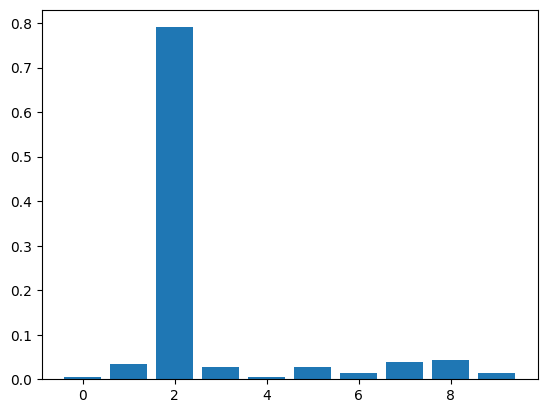

In [178]:
probas = rf.predict_proba(X_3)
for i, p in enumerate(probas[0]):
    print(f"Digito {i}: {p:.3f}")

plt.bar([i for i in range(10)],probas[0])